# **MÓDULO 19**
# Exercício: Estatística Aplicada

**Efetividade de Duas Estratégias de Ensino**

Imagine que uma escola esteja avaliando a eficácia de duas estratégias de ensino de matemática para alunos do ensino médio. Eles querem determinar se há uma diferença significativa no desempenho médio dos alunos entre as duas estratégias.

# **Hipóteses:**

* Hipótese nula (H0): A média das notas dos alunos na estratégia A é igual à média das notas dos alunos na estratégia B.
* Hipótese alternativa (H1): A média das notas na Estratégia B é maior do que a média das notas na Estratégia A.

# **Dados:**

* Amostra da Estratégia A: Notas de 50 alunos que receberam a Estratégia A.
* Amostra da Estratégia B: Notas de 50 alunos que receberam a Estratégia B.

Usaremos um teste Z para comparar as médias das notas entre as duas amostras.

Se o p-valor do teste Z for menor que um nível de significância pré-determinado (por exemplo, α = 0.05), rejeitamos a hipótese nula e concluímos que há uma diferença significativa nas médias das notas entre as duas estratégias de ensino.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm
import seaborn as sns

Os dados são criados a seguir:

In [3]:
# Definindo médias e desvios padrão para as notas nas duas estratégias
media_estrategia_A = 70
desvio_padrao_estrategia_A = 10

media_estrategia_B = 75
desvio_padrao_estrategia_B = 12

# Gerando as amostras de notas para cada estratégia de ensino da nossa base
np.random.seed(0)  # Para garantir a reprodutibilidade dos resultados
amostra_estrategia_A = np.random.normal(loc=media_estrategia_A, scale=desvio_padrao_estrategia_A, size=50)
amostra_estrategia_B = np.random.normal(loc=media_estrategia_B, scale=desvio_padrao_estrategia_B, size=50)

print("Notas da Estratégia A:", amostra_estrategia_A[:5])
print("Notas da Estratégia B:", amostra_estrategia_B[:5])

Notas da Estratégia A: [87.64052346 74.00157208 79.78737984 92.40893199 88.6755799 ]
Notas da Estratégia B: [64.25440127 79.64282997 68.87033835 60.83241379 74.66181326]


# 1) De acordo com as informações analisadas o nosso teste é unilateral á direita, esquerda ou bicaudal? Justifique.




Entendo que o Teste Unilateral será para à Direita, considerando que a Hipótese Alternativa possui o sinal >

Ha = A Média da Estratégia B é maior que a Média da Estratégia A

# 2) Calcule as médias para as duas amostragens e as variâncias. Quais insights você pode retirar comparando os dados?

In [4]:
#Seu código aqui
media_A = amostra_estrategia_A.mean()
variancia_A = amostra_estrategia_A.var(ddof = 1)
print(
    "Média Estratégia A:", media_A,
    "\nVariância Amostral A:", variancia_A
)

media_B = amostra_estrategia_B.mean()
variancia_B = amostra_estrategia_B.var(ddof = 1)

print(
    "\nMédia Estratégia B:", media_B,
    "\nVariância Amostral B:", variancia_B
)

dif_media = (1 - media_A / media_B) * 100
dif_var = (1 - variancia_B / variancia_A) * 100
print(
    "\nDiferença % Média:", dif_media.round(2),
    "\nDiferença % Variância:", dif_var.round(2)
)

Média Estratégia A: 71.40559272313098 
Variância Amostral A: 129.2654943565623

Média Estratégia B: 74.74868110507046 
Variância Amostral B: 110.4700206552835

Diferença % Média: 4.47 
Diferença % Variância: 14.54


A média da Estratégia B é cerca de 4,48% maior que a média da Estratégia A, porém, a variância da Estratégia A é cerca de 14,54% maior que a variância da Estratégia B.

A partir dessas métricas, podemos levantar a hipótese que a Estratégia B é mais eficaz que a Estratégia A, pois aparenta ser ligeiramente mais performática (média maior) e mais consistente (menor variância).

# 3) Imprima os resultados da estatística do teste Z, p value e indique se rejeitaremos ou não a hipótese nula. Justifique sua resposta.

In [5]:
# Calculando a estatística do teste Z
z_stat = (media_B - media_A) / np.sqrt(variancia_A / len(amostra_estrategia_A))

# Calculando o P-Value do Teste Unilateral à Direita
p_value = 1 - stats.norm.cdf(z_stat)

nivel_significancia = 0.05

print(
    "Estatística Z:", z_stat,
    "\nP-Value:", p_value
)

if p_value < nivel_significancia:
    print("\nRejeitamos a Hipótese Nula: A Estratégia A possui uma média significativamente menor que a Estratégia B.")
else:
    print("\nAceitamos a Hipótese Nula: A média da Estratégia B é igual média da Estratégia A.")


Estatística Z: 2.079177442431837 
P-Value: 0.018800522095295147

Rejeitamos a Hipótese Nula: A Estratégia A possui uma média significativamente menor que a Estratégia B


# 4) Para finalizar monte o gráfico da distribuição da estatística do nosso teste Z e explique o que pode ser observado através dele.

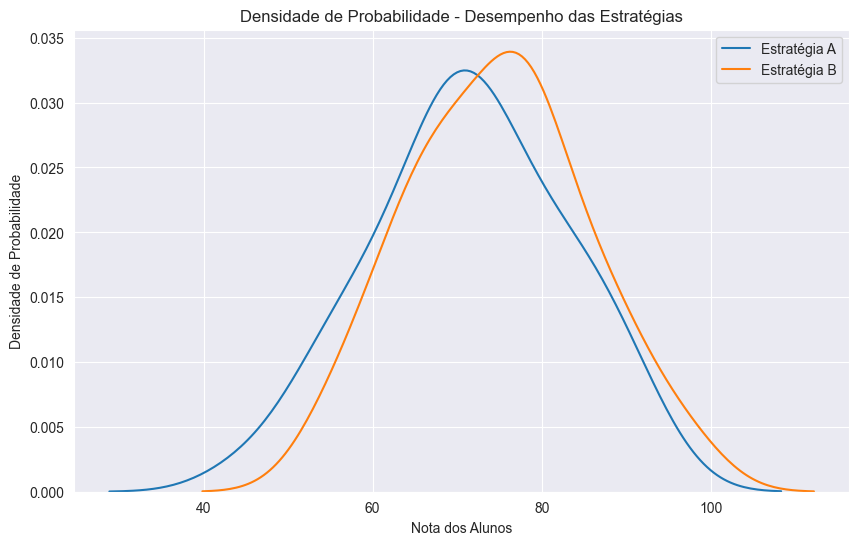

In [6]:
plt.figure(figsize=(10,6))
sns.kdeplot(amostra_estrategia_A, label='Estratégia A')
sns.kdeplot(amostra_estrategia_B, label='Estratégia B')

plt.title('Densidade de Probabilidade - Desempenho das Estratégias')
plt.xlabel('Nota dos Alunos')
plt.ylabel('Densidade de Probabilidade')
plt.legend()
plt.show()

### **_Insight_**

Podemos observar que a Estrátégia B tende uma distribuição média maior que a Estratégia A, portanto, podemos pré-supor que há uma diferença relevante entre as duas estratégias.

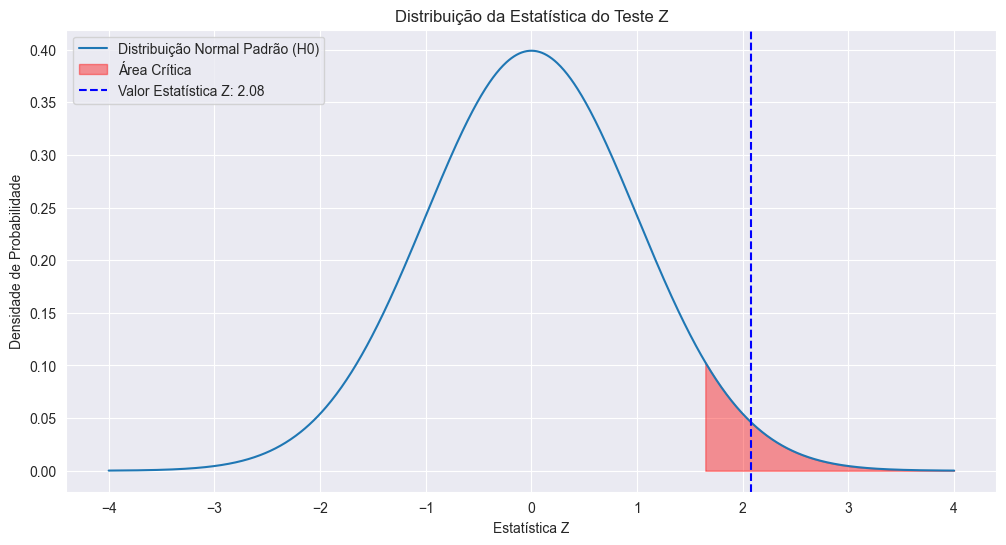

In [10]:
# Definindo o eixo X
x = np.linspace(-4, 4, 1000)

# Gráfico de Densidade - Estratégia A
plt.figure(figsize = (12, 6))
plt.plot(
    x,
    norm.pdf(x, 0, 1),
    label = 'Distribuição Normal Padrão (H0)'
)

# ÁREA CRÍTICA
alpha = 0.05 # Nível de Significância
z_crit = norm.ppf(1 - alpha) # Valor Crítico

# Preenchendo a área crítica no gráfico
plt.fill_between(
    x,
    0,
    norm.pdf(x),
    where = (x > z_crit),
    color = 'red',
    alpha = 0.4,
    label = 'Área Crítica'
)

# VALOR Z
plt.axvline(
    z_stat,
    color = 'blue',
    linestyle = '--',
    label = f'Valor Estatística Z: {z_stat:.2f}'
)

# PERSONALIZAÇÃO FINAL
plt.xlabel('Estatística Z')
plt.ylabel('Densidade de Probabilidade')
plt.title('Distribuição da Estatística do Teste Z')
plt.legend()
plt.show()


### **_Insight_**

Como podemos observar, o Valor Z se encontra dentro da Área Crítica, portanto, podemos rejeitar a Hipótese Nula e fazer a seguinte afirmação:

"A partir dos resultados do Teste Z, podemos observar que a diferença média entre as estratégias não é fruto do acaso, e que de fato, a Estratégia B é mais eficaz que a Estratégia A."